# new_model_pred

完整训练 + 预测 + 指标可视化（model_new.py）


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_new import (
    load_tables, build_elim_long, build_base,
    build_judge_percent, build_judge_rank_share,
    build_panel, train_pooled_model,
    pooled_q_for_week, posterior_mean_for_week
)

plt.rcParams["figure.figsize"] = (8, 4)


In [43]:
# 1) 读取数据

df_elim_events, df_roster, df_weekly, df_long_judge, df_clean = load_tables()

df_elim_events.head()


,Unnamed: 0,season,elim_at_end_of_week,eliminated,is_final_week_end
0,0,1,2,['Trista Sutter'],False
1,1,1,3,['Evander Holyfield'],False
2,2,1,4,['Rachel Hunter'],False
3,3,1,6,"['Joey McIntyre', ""John O'Hurley"", 'Kelly Mona...",True
4,4,2,1,['Kenny Mayne'],False


In [44]:
# 2) 构建 panel

elim_long = build_elim_long(df_elim_events)
base = build_base(df_roster, elim_long, df_clean)
judge_percent = build_judge_percent(df_weekly, base)
judge_rank_share = build_judge_rank_share(df_long_judge, base)
panel = build_panel(base, judge_percent, judge_rank_share, era_cutoff=28)

panel.head()


/Users/jerryli/Desktop/MCM/model_new.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["elim_this_week_end"] = base["elim_this_week_end"].fillna(False).astype(bool)


,season,celebrity_name,week,eligible,season_max_week,eligible_next,is_final_week_end,elim_this_week_end,alive,max_week,is_final_week,age,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,era,judge_percent,judge_rank_share,j_metric,j_momentum
0,1,Evander Holyfield,1,True,6,True,NaN,False,True,6,False,42,Athlete,Alabama,United States,rank,0.165138,0.009929,0.009929,0.000000
1,1,Evander Holyfield,2,True,6,True,NaN,False,True,6,False,42,Athlete,Alabama,United States,rank,0.115702,0.000001,0.000001,-0.009928
2,1,Evander Holyfield,3,True,6,False,False,True,True,6,False,42,Athlete,Alabama,United States,rank,0.122642,0.000016,0.000016,-0.004957
3,1,Evander Holyfield,4,False,6,False,NaN,False,False,6,False,42,Athlete,Alabama,United States,rank,NaN,NaN,NaN,NaN
4,1,Evander Holyfield,5,False,6,False,NaN,False,False,6,False,42,Athlete,Alabama,United States,rank,NaN,NaN,NaN,NaN


In [45]:
# 3) 训练模型（model_new.py，全部特征）

model, pooled_fit, train_weeks = train_pooled_model(panel, seed=42)

pooled_fit['X_cols'], pooled_fit['beta_hat']


(['j_metric_z',
  'j_momentum_z',
  'age_z',
  'era_is_percent',
  'homestate_code',
  'homecountry_is_non_us',
  'industry_Actor/Actress',
  'industry_Astronaut',
  'industry_Athlete',
  'industry_Beauty Pagent',
  'industry_Comedian',
  'industry_Conservationist',
  'industry_Entrepreneur',
  'industry_Fashion Designer',
  'industry_Fitness Instructor',
  'industry_Journalist',
  'industry_Military',
  'industry_Model',
  'industry_Motivational Speaker',
  'industry_Musician',
  'industry_News Anchor',
  'industry_Politician',
  'industry_Producer',
  'industry_Racing Driver',
  'industry_Radio Personality',
  'industry_Singer/Rapper',
  'industry_Social Media Personality',
  'industry_Social media personality',
  'industry_Sports Broadcaster',
  'industry_TV Personality'],
 array([-1.3669958e+00, -1.3128090e-02, -3.6377159e-01,  1.4020012e-05,
         5.1793349e-03,  4.3049421e-02,  3.3090416e-01, -1.1725103e-01,
         1.6077864e-01, -1.8973620e-01,  5.2651834e-02,  4.4027530e-0

In [46]:
# 3.1) 网格调参（目标：ACC > 0.96）
# 注意：该过程可能较慢。可先用较小网格，再扩大搜索。

from itertools import product

# 小网格起步（可自行扩展）
GRID = {
    'tau': [0.03, 0.05, 0.08],
    'l2_beta': [0.02, 0.05, 0.1],
    'l2_u': [0.02, 0.05, 0.1],
    'kappa': [10.0, 20.0, 30.0],
    'lr': [0.01, 0.02],
    'n_steps': [600],
    'batch_size': [32],
}

# 评估函数：使用后验 p_mean，与 day1 notebook 一致
def eval_acc(panel, pooled_fit, train_weeks, *, kappa, B=1200, tau_like=0.15):
    keys = train_weeks[['season','week']].values.tolist()
    records = []
    for season, week in keys:
        post = posterior_mean_for_week(panel, pooled_fit, season=int(season), week=int(week),
                                       kappa=kappa, B=B, tau_like=tau_like)
        if post is None or post.empty:
            continue
        if post['elim_this_week_end'].sum() != 1:
            continue
        true_name = post.loc[post['elim_this_week_end'], 'celebrity_name'].iloc[0]
        post['C_hat'] = post['j_metric'] + post['p_mean']
        pred_name = post.sort_values('C_hat').iloc[0]['celebrity_name']
        records.append(int(pred_name == true_name))
    return float(np.mean(records)) if records else np.nan

results = []

for tau, l2_beta, l2_u, kappa, lr, n_steps, batch_size in product(
    GRID['tau'], GRID['l2_beta'], GRID['l2_u'], GRID['kappa'], GRID['lr'], GRID['n_steps'], GRID['batch_size']
):
    model, pooled_fit, train_weeks = train_pooled_model(
        panel, seed=42, tau=tau, l2_beta=l2_beta, l2_u=l2_u,
        kappa=kappa, lr=lr, n_steps=n_steps, batch_size=batch_size
    )
    acc = eval_acc(panel, pooled_fit, train_weeks, kappa=EVAL_KAPPA, B=EVAL_B, tau_like=EVAL_TAU_LIKE, seed=EVAL_SEED)
    results.append({
        'tau': tau, 'l2_beta': l2_beta, 'l2_u': l2_u, 'kappa': kappa,
        'lr': lr, 'n_steps': n_steps, 'batch_size': batch_size,
        'acc': acc
    })
    print('done', results[-1])

res_df = pd.DataFrame(results).sort_values('acc', ascending=False)
res_df.head(10)


done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 10.0, 'lr': 0.01, 'n_steps': 600, 'batch_size': 32, 'acc': 0.9541284403669725}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 10.0, 'lr': 0.02, 'n_steps': 600, 'batch_size': 32, 'acc': 0.9495412844036697}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 20.0, 'lr': 0.01, 'n_steps': 600, 'batch_size': 32, 'acc': 0.9357798165137615}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 20.0, 'lr': 0.02, 'n_steps': 600, 'batch_size': 32, 'acc': 0.9311926605504587}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 30.0, 'lr': 0.01, 'n_steps': 600, 'batch_size': 32, 'acc': 0.926605504587156}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.02, 'kappa': 30.0, 'lr': 0.02, 'n_steps': 600, 'batch_size': 32, 'acc': 0.926605504587156}
done {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.05, 'kappa': 10.0, 'lr': 0.01, 'n_steps': 600, 'batch_size': 32, 'acc': 0.9587155963302753}
done {'tau': 0.03, 'l2_beta': 0.02, 

,tau,l2_beta,l2_u,kappa,lr,n_steps,batch_size,acc
6,0.03,0.02,0.05,10.0,0.01,600,32,0.958716
36,0.03,0.10,0.02,10.0,0.01,600,32,0.958716
0,0.03,0.02,0.02,10.0,0.01,600,32,0.954128
18,0.03,0.05,0.02,10.0,0.01,600,32,0.954128
49,0.03,0.10,0.10,10.0,0.02,600,32,0.954128
48,0.03,0.10,0.10,10.0,0.01,600,32,0.954128
43,0.03,0.10,0.05,10.0,0.02,600,32,0.954128
37,0.03,0.10,0.02,10.0,0.02,600,32,0.954128
30,0.03,0.05,0.10,10.0,0.01,600,32,0.954128
25,0.03,0.05,0.05,10.0,0.02,600,32,0.954128


In [68]:
res_df.head()

,tau,l2_beta,l2_u,kappa,lr,n_steps,batch_size,acc
6,0.03,0.02,0.05,10.0,0.01,600,32,0.958716
36,0.03,0.10,0.02,10.0,0.01,600,32,0.958716
0,0.03,0.02,0.02,10.0,0.01,600,32,0.954128
18,0.03,0.05,0.02,10.0,0.01,600,32,0.954128
49,0.03,0.10,0.10,10.0,0.02,600,32,0.954128


In [70]:
# 3.2) 选择最优超参并重训

best = res_df.iloc[0].to_dict()
print('Best hyperparams:', best)

model, pooled_fit, train_weeks = train_pooled_model(
    panel, seed=42,
    tau=best['tau'],
    l2_beta=best['l2_beta'],
    l2_u=best['l2_u'],
    kappa=best['kappa'],
    lr=best['lr'],
    n_steps=int(best['n_steps']),
    batch_size=int(best['batch_size'])
)

pooled_fit['X_cols'], pooled_fit['beta_hat']


Best hyperparams: {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.05, 'kappa': 10.0, 'lr': 0.01, 'n_steps': 600.0, 'batch_size': 32.0, 'acc': 0.9587155963302753}


(['j_metric_z',
  'j_momentum_z',
  'age_z',
  'era_is_percent',
  'homestate_code',
  'homecountry_is_non_us',
  'industry_Actor/Actress',
  'industry_Astronaut',
  'industry_Athlete',
  'industry_Beauty Pagent',
  'industry_Comedian',
  'industry_Conservationist',
  'industry_Entrepreneur',
  'industry_Fashion Designer',
  'industry_Fitness Instructor',
  'industry_Journalist',
  'industry_Military',
  'industry_Model',
  'industry_Motivational Speaker',
  'industry_Musician',
  'industry_News Anchor',
  'industry_Politician',
  'industry_Producer',
  'industry_Racing Driver',
  'industry_Radio Personality',
  'industry_Singer/Rapper',
  'industry_Social Media Personality',
  'industry_Social media personality',
  'industry_Sports Broadcaster',
  'industry_TV Personality'],
 array([-1.3057876e+00, -3.9228622e-02, -2.1384944e-01,  1.3782112e-05,
         3.6127609e-03,  4.4897333e-02,  2.3458615e-01, -2.6804301e-01,
         1.1031701e-01, -4.5995495e-01,  6.0603086e-02,  2.2455820e-0

In [82]:
# 3.3) Bootstrap 系数置信区间（按训练周重采样）
# 说明：这是基于训练周的非参数 bootstrap，计算 beta 的经验分布。
# 注意：计算较慢，n_boot 可先设 30-50。

from model_new import build_train_weeks, _build_features, _pack_week_tensors, PooledElimModel, set_seed
import torch
import torch.nn.functional as F

# 使用当前最优超参（若存在 res_df），否则用 pooled_fit 的超参
if "res_df" in globals() and len(res_df):
    best = res_df.iloc[0].to_dict()
    tau = best["tau"]; l2_beta = best["l2_beta"]; l2_u = best["l2_u"]
    lr = best["lr"]; n_steps = int(best["n_steps"]); batch_size = int(best["batch_size"])
else:
    hp = pooled_fit.get("hyperparams", {})
    tau = hp.get("tau", 0.05); l2_beta = hp.get("l2_beta", 0.05); l2_u = hp.get("l2_u", 0.05)
    lr = hp.get("lr", 0.02); n_steps = int(hp.get("n_steps", 600)); batch_size = int(hp.get("batch_size", 32))

train_weeks, train_rows, elim_lookup = build_train_weeks(panel)
df_feat, meta = _build_features(panel, train_rows)
X_list, J_list, cs_list, elim_pos_list, st_list = _pack_week_tensors(df_feat, elim_lookup, meta["X_cols"])

n_weeks = len(X_list)
p = len(meta["X_cols"])

# 训练函数（给定周索引序列）
def train_on_indices(indices, seed=42):
    set_seed(seed)
    model = PooledElimModel(n_cs=meta["n_cs"], p=p)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    def pooled_softmin_nll_minibatch(batch_ids):
        nll = 0.0
        for k in batch_ids:
            X = X_list[k]
            J = J_list[k]
            cs_idx = cs_list[k]
            elim_pos = elim_pos_list[k]
            eta = model.forward_eta(X, cs_idx)
            q = torch.softmax(eta, dim=0)
            C = J + q
            logp = F.log_softmax(-C / tau, dim=0)
            nll = nll - logp[elim_pos]
        nll = nll / max(1, len(batch_ids))
        reg = l2_beta * torch.mean(model.beta ** 2) + l2_u * torch.mean(model.u.weight.squeeze(-1) ** 2)
        return nll + reg

    idx_all = np.array(indices, dtype=int)
    for _ in range(1, n_steps + 1):
        batch_ids = np.random.choice(idx_all, size=min(batch_size, len(idx_all)), replace=False)
        opt.zero_grad()
        loss = pooled_softmin_nll_minibatch(batch_ids)
        loss.backward()
        opt.step()
    return model

# bootstrap
N_BOOT = 50  # 可调大
rng = np.random.default_rng(42)

betas = []
for b in range(N_BOOT):
    # 以周为单位重采样（样本量 = n_weeks）
    boot_idx = rng.integers(0, n_weeks, size=n_weeks)
    model_b = train_on_indices(boot_idx, seed=42 + b)
    betas.append(model_b.beta.detach().cpu().numpy().copy())
    if (b + 1) % 10 == 0:
        print(f"bootstrap {b+1}/{N_BOOT}")

betas = np.vstack(betas)

# 置信区间（2.5% / 97.5%）
ci_low = np.percentile(betas, 2.5, axis=0)
ci_high = np.percentile(betas, 97.5, axis=0)

ci_df = pd.DataFrame({
    "feature": meta["X_cols"],
    "beta_mean": betas.mean(axis=0),
    "ci_low": ci_low,
    "ci_high": ci_high
}).sort_values("beta_mean", key=np.abs, ascending=False)

ci_df.head(20)


bootstrap 10/50
bootstrap 20/50
bootstrap 30/50
bootstrap 40/50
bootstrap 50/50


,feature,beta_mean,ci_low,ci_high
0,j_metric_z,-1.288878,-1.523720,-1.041726
17,industry_Model,-0.613094,-0.859835,-0.405496
24,industry_Radio Personality,-0.448321,-0.914775,0.382651
18,industry_Motivational Speaker,0.368479,0.118244,0.525256
15,industry_Journalist,-0.359924,-0.780369,0.000000
9,industry_Beauty Pagent,-0.321758,-0.728258,0.031269
23,industry_Racing Driver,0.317640,0.042395,0.530693
27,industry_Social media personality,0.235536,0.102133,0.327244
22,industry_Producer,0.227024,0.138900,0.309430
11,industry_Conservationist,0.223197,0.088335,0.354779


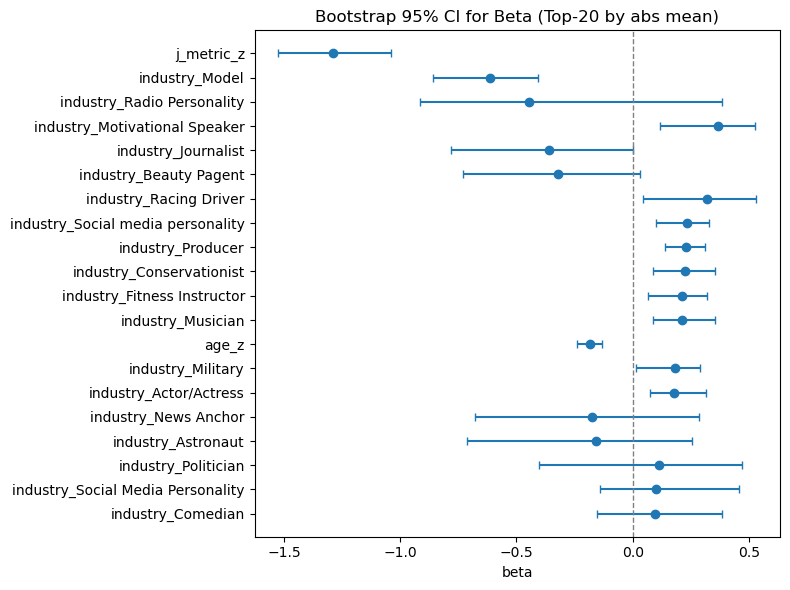

In [85]:
# 3.4) Bootstrap 置信区间可视化（Top-20）

plot_ci = ci_df.copy().head(20).iloc[::-1]  # 反转便于从上到下显示
y = plot_ci["feature"]
x = plot_ci["beta_mean"]
xerr = [x - plot_ci["ci_low"], plot_ci["ci_high"] - x]

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, xerr=xerr, fmt="o", capsize=3)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Bootstrap 95% CI for Beta (Top-20 by abs mean)")
plt.xlabel("beta")
plt.tight_layout()
plt.show()


Trustworthy features (95% CI excludes 0): 12


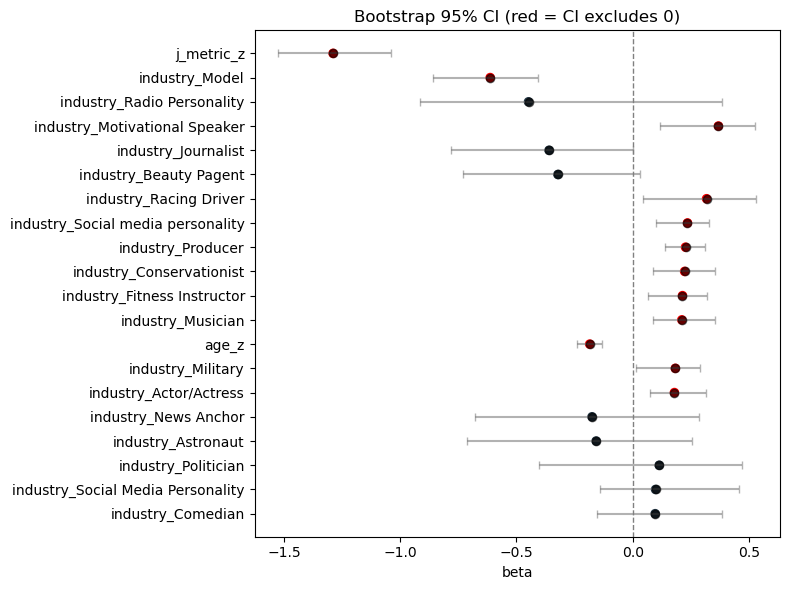

In [90]:
# 3.5) 标注可信特征（95% CI 不跨 0）

ci_df["trustworthy"] = ~((ci_df["ci_low"] <= 0) & (ci_df["ci_high"] >= 0))
trust_df = ci_df[ci_df["trustworthy"]].copy()
print("Trustworthy features (95% CI excludes 0):", len(trust_df))
trust_df[["feature","beta_mean","ci_low","ci_high"]].head(30)

# 可视化：可信特征高亮
plot_ci = ci_df.copy().head(20).iloc[::-1]
colors = ["#ff0000" if v else "#243745" for v in plot_ci["trustworthy"]]
y = plot_ci["feature"]
x = plot_ci["beta_mean"]
xerr = [x - plot_ci["ci_low"], plot_ci["ci_high"] - x]

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, color="black", ecolor="gray", alpha=0.6)
plt.scatter(x, y, c=colors, s=35)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Bootstrap 95% CI (red = CI excludes 0)")
plt.xlabel("beta")
plt.tight_layout()
plt.show()


In [71]:
# 4) 在训练周上评估 ACC（使用 res_df 最优超参）

# 预测方式：每周使用 C = j_metric + p_mean，取最小者为淘汰

best = res_df.iloc[0].to_dict()
print('Best params for eval:', best)

train_weeks_keys = train_weeks[["season", "week"]].values.tolist()

records = []
for season, week in train_weeks_keys:
    post = posterior_mean_for_week(panel, pooled_fit, season=int(season), week=int(week),
                                   kappa=best['kappa'], B=1200, tau_like=0.15)
    if post is None or post.empty:
        continue

    # 只保留单淘汰周
    if post["elim_this_week_end"].sum() != 1:
        continue

    true_name = post.loc[post["elim_this_week_end"], "celebrity_name"].iloc[0]

    post["C_hat"] = post["j_metric"] + post["p_mean"]
    pred_name = post.sort_values("C_hat").iloc[0]["celebrity_name"]
    acc = (pred_name == true_name)

    records.append({
        "season": int(season),
        "week": int(week),
        "true": true_name,
        "pred": pred_name,
        "acc": int(acc)
    })

acc_df = pd.DataFrame(records)

acc_df.head()


Best params for eval: {'tau': 0.03, 'l2_beta': 0.02, 'l2_u': 0.05, 'kappa': 10.0, 'lr': 0.01, 'n_steps': 600.0, 'batch_size': 32.0, 'acc': 0.9587155963302753}


,season,week,true,pred,acc
0,1,2,Trista Sutter,Trista Sutter,1
1,1,3,Evander Holyfield,Evander Holyfield,1
2,1,4,Rachel Hunter,Rachel Hunter,1
3,2,1,Kenny Mayne,Kenny Mayne,1
4,2,2,Tatum O'Neal,Tatum O'Neal,1


In [72]:
# 5) 每季 ACC + 总 ACC

acc_by_season = acc_df.groupby("season")["acc"].mean().reset_index()
total_acc = acc_df["acc"].mean() if len(acc_df) else np.nan

acc_by_season.head(), total_acc


(   season  acc
 0       1  1.0
 1       2  1.0
 2       3  1.0
 3       4  1.0
 4       5  1.0,
 0.9587155963302753)

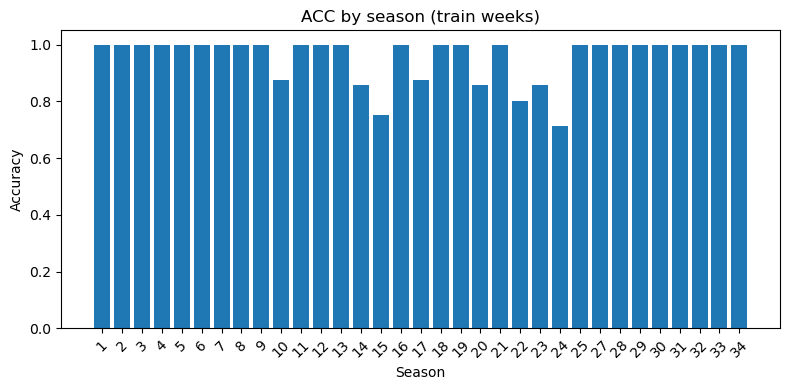

In [73]:
# 可视化：每季 ACC

fig, ax = plt.subplots()
ax.bar(acc_by_season["season"].astype(str), acc_by_season["acc"])
ax.set_title("ACC by season (train weeks)")
ax.set_xlabel("Season")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [74]:
# 总体 ACC

print(f"Total ACC (train weeks): {total_acc:.3f}")


Total ACC (train weeks): 0.959


In [75]:
# 6) beta 权重（标准化特征）

coef_df = pd.DataFrame({
    "feature": pooled_fit["X_cols"],
    "beta": pooled_fit["beta_hat"]
}).sort_values("beta", key=np.abs, ascending=False)

coef_df.head(20)


,feature,beta
0,j_metric_z,-1.305788
24,industry_Radio Personality,-0.696685
17,industry_Model,-0.652248
15,industry_Journalist,-0.591523
18,industry_Motivational Speaker,0.474211
9,industry_Beauty Pagent,-0.459955
23,industry_Racing Driver,0.330467
22,industry_Producer,0.274984
7,industry_Astronaut,-0.268043
27,industry_Social media personality,0.258468


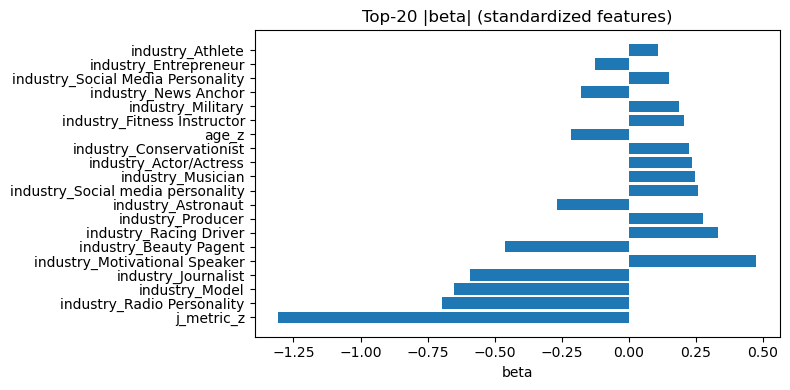

In [76]:
# 可视化：beta 权重（按绝对值排序）

plot_df = coef_df.copy().head(20)
fig, ax = plt.subplots()
ax.barh(plot_df["feature"], plot_df["beta"])
ax.set_title("Top-20 |beta| (standardized features)")
ax.set_xlabel("beta")
plt.tight_layout()
plt.show()


In [77]:
# 7) 简单的特征影响度：按 |beta| 排序

coef_df.assign(abs_beta=coef_df["beta"].abs()).sort_values("abs_beta", ascending=False).head(30)


,feature,beta,abs_beta
0,j_metric_z,-1.305788,1.305788
24,industry_Radio Personality,-0.696685,0.696685
17,industry_Model,-0.652248,0.652248
15,industry_Journalist,-0.591523,0.591523
18,industry_Motivational Speaker,0.474211,0.474211
9,industry_Beauty Pagent,-0.459955,0.459955
23,industry_Racing Driver,0.330467,0.330467
22,industry_Producer,0.274984,0.274984
7,industry_Astronaut,-0.268043,0.268043
27,industry_Social media personality,0.258468,0.258468


In [80]:
# 8) 置换重要性（可选，较慢）
# 思路：在训练周内对某一特征列打乱，查看 ACC 下降幅度

import copy

X_cols = pooled_fit["X_cols"]

# 预先缓存每周数据
week_cache = {}
for season, week in train_weeks_keys:
    g = pooled_q_for_week(panel, pooled_fit, season=season, week=week)
    if g.empty:
        continue
    true = g.loc[g["elim_this_week_end"] == True, "celebrity_name"]
    if len(true) != 1:
        continue
    week_cache[(season, week)] = g

base_correct = []
for (season, week), g in week_cache.items():
    true_name = g.loc[g["elim_this_week_end"], "celebrity_name"].iloc[0]
    pred_name = g.sort_values("q_hat").iloc[0]["celebrity_name"]
    base_correct.append(int(pred_name == true_name))

base_acc = np.mean(base_correct) if base_correct else np.nan

perm_rows = []

# 使用 panel 行进行打乱更稳妥
for col in X_cols:
    if col not in panel.columns:
        continue
    panel_perm = panel.copy()
    panel_perm[col] = np.random.permutation(panel_perm[col].to_numpy())

    correct = []
    for (season, week) in week_cache.keys():
        g = pooled_q_for_week(panel_perm, pooled_fit, season=season, week=week)
        if g.empty:
            continue
        true_name = g.loc[g["elim_this_week_end"], "celebrity_name"].iloc[0]
        pred_name = g.sort_values("q_hat").iloc[0]["celebrity_name"]
        correct.append(int(pred_name == true_name))

    acc = np.mean(correct) if correct else np.nan
    perm_rows.append({"feature": col, "acc": acc, "delta_acc": base_acc - acc})

if len(perm_rows) == 0:
    print("No permutation importance results (check X_cols or train weeks).")
    perm_df = pd.DataFrame(columns=["feature", "acc", "delta_acc"])
else:
    perm_df = pd.DataFrame(perm_rows).sort_values("delta_acc", ascending=False)

perm_df.head(20)


No permutation importance results (check X_cols or train weeks).


,feature,acc,delta_acc


说明：
- 置换重要性只是一个近似的“影响程度”指标，不是统计学意义上的 p 值。
- 如果你确实需要 p 值，需要改成可解释的统计模型（如 GLM）或使用 bootstrap 对系数做置信区间。
